In [62]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [63]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/hot-dog-not-hot-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hot-dog-not-hot-dog' dataset.
Path to dataset files: /kaggle/input/hot-dog-not-hot-dog


In [64]:
# Use the 'path' variable from the kagglehub download
train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")

# Now the counting code will work!
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# YOUR CODE HERE: Print the number of test images
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test hot dog images: {test_hot_dog_count}")
print(f"Test not hot dog images: {test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250


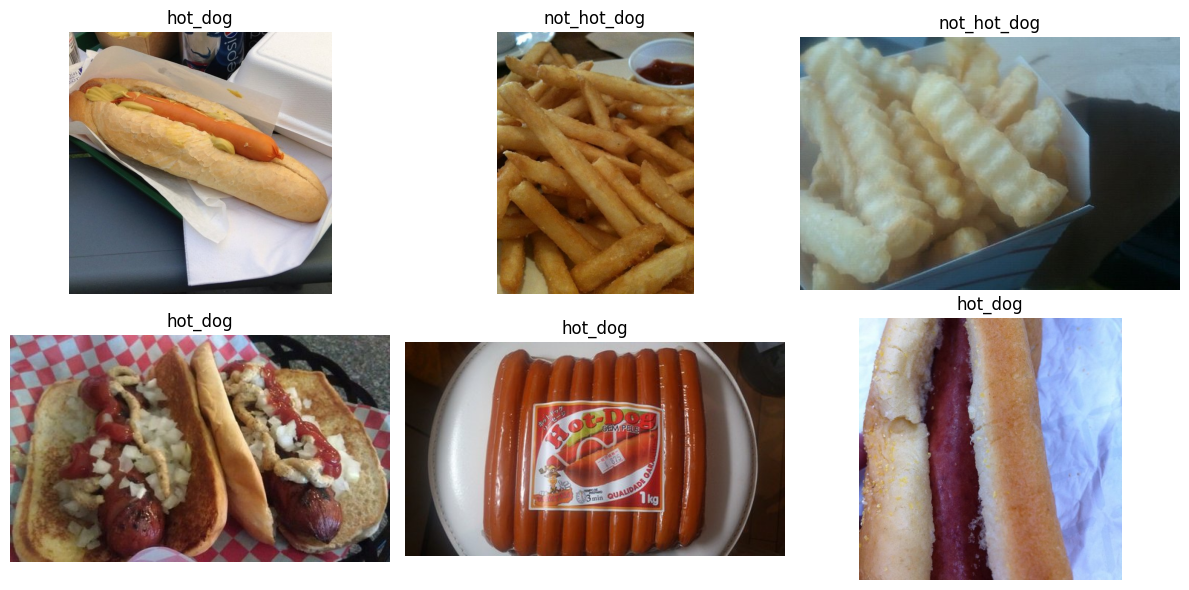

Typical image shape (H, W, Channels): (512, 512, 3)


In [65]:
# Display 6 random images
plt.figure(figsize=(12,6))

for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# YOUR CODE HERE: Print the shape of one image
print(f"Typical image shape (H, W, Channels): {img.shape}")

In [66]:
# Set image size (64x64 is faster for GIKI's CEP) [cite: 103, 104]
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32

# Create generators with automatic labeling [cite: 107]
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# YOUR CODE HERE: Print the class labels [cite: 127]
print("Class Indices:", train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class Indices: {'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.4975 - loss: 0.9433 - val_accuracy: 0.5204 - val_loss: 0.7287
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.5700 - loss: 0.6902 - val_accuracy: 0.5816 - val_loss: 0.6807
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.6650 - loss: 0.6205 - val_accuracy: 0.5102 - val_loss: 0.8422
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6150 - loss: 0.6964 - val_accuracy: 0.5102 - val_loss: 0.9978
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.6400 - loss: 0.6362 - val_accuracy: 0.5714 - val_loss: 0.7051
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.7175 - loss: 0.5587 - val_accuracy: 0.5408 - val_loss: 0.7887
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.7550 - loss: 0.5356 - val_accuracy: 0.5612 - val_loss: 0.7235
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.7325 - loss: 0.5144 - val_accuracy: 0.

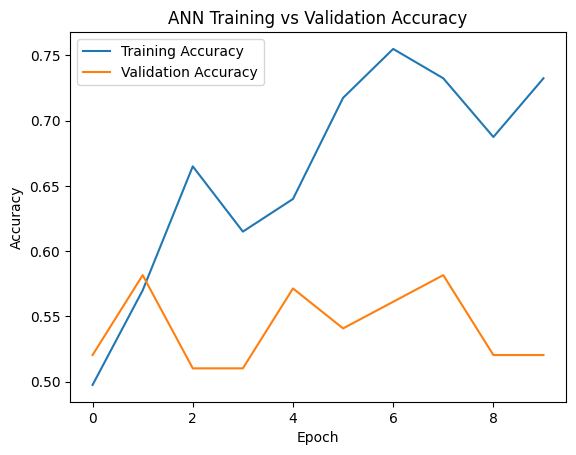

In [67]:
# Build a simple ANN
ann_model = keras.Sequential([
    # Flatten the 2D image into 1D
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Show model summary
ann_model.summary()

# Train for 10 epochs
history_ann = ann_model.fit(train_generator, validation_data=validation_generator, epochs=10)

# Plot training vs validation accuracy
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 325ms/step - accuracy: 0.4875 - loss: 0.7001 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.5175 - loss: 0.6899 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.5375 - loss: 0.6820 - val_accuracy: 0.6020 - val_loss: 0.6807
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.6075 - loss: 0.6765 - val_accuracy: 0.6327 - val_loss: 0.6801
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.6300 - loss: 0.6797 - val_accuracy: 0.5714 - val_loss: 0.6677
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.6250 - loss: 0.6489 - val_accuracy: 0.5816 - val_loss: 0.6769
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.6625 - loss: 0.6407 - val_accuracy: 0.6020 - val_loss: 0.6640
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 353ms/step - accuracy: 0.6800 - loss: 0.5949 - val_accuracy: 0.

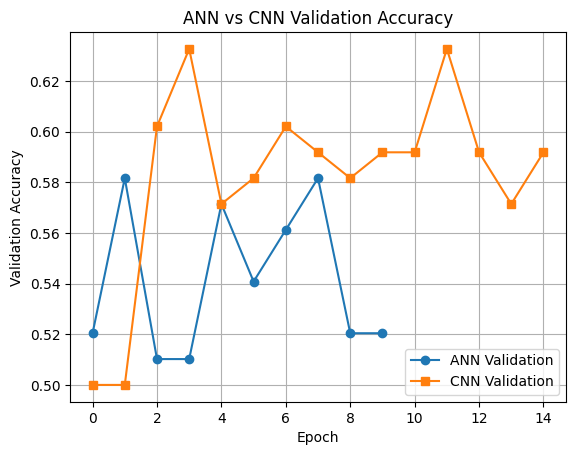

In [68]:
# Build the CNN model
cnn_model = keras.Sequential([
    # First Conv layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv layer (Your Turn addition)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the CNN
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the CNN (15 epochs)
history_cnn = cnn_model.fit(train_generator, validation_data=validation_generator, epochs=15)

# Plot the comparison between ANN and CNN
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

In [69]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup Data Augmentation
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, # [cite: 256]
    width_shift_range=0.1, # [cite: 257]
    height_shift_range=0.1, # [cite: 258]
    horizontal_flip=True, # [cite: 259]
    validation_split=0.2 # [cite: 261]
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training' # [cite: 268]
)

# 2. Build the Final Model with Dropout
final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # First Dropout [cite: 225, 276]

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Second Dropout [cite: 225, 279]

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Third Dropout before output [cite: 225, 284]
    layers.Dense(1, activation='sigmoid')
])

# 3. Compile and Train
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_final = final_model.fit(train_augmented, validation_data=validation_generator, epochs=15)

# 4. Plot Before/After Comparison
plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)S
plt.show()

SyntaxError: invalid syntax (3269499586.py, line 51)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_local_image(image_path):
    # 1. Load the image from your Colab files
    img = image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))

    # 2. Process and Predict
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    prediction = final_model.predict(img_array)[0][0]

    # 3. Show Result
    if prediction > 0.5:
        print(f"🌭 HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"❌ NOT A HOT DOG! (confidence: {1-prediction:.2f})")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

# TEST: Use the path of the file you just uploaded
# Example: predict_local_image("/content/my_burger.jpg")
predict_local_image("/content/hotdog.jpg")

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt")

# Run detection on your local hot dog image
results = yolo_model("/content/hotdog.jpg")

# Show results (it should draw a box)
results[0].show()